In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy import stats

In [2]:
df = pd.read_csv('E:\AI_Projects\Machine_Learning\simara_air_quality\simara_1year_hourly.csv')

In [3]:
df

,Date,AQI,PM2.5_ugm3,Total_Respiratory_Visits,Pneumonia_Cases,Asthma_Cases,COPD_Cases,Bronchitis_Cases,Other_Respiratory_Cases
0,2025-01-01,79,25.414286,337,85,93,52,77,30
1,2025-01-02,69,20.659184,343,77,119,53,59,35
2,2025-01-03,80,25.889796,383,101,121,67,62,32
3,2025-01-04,66,19.232653,227,58,65,40,44,20
4,2025-01-05,63,17.806122,175,53,51,27,28,16
...,...,...,...,...,...,...,...,...,...
354,2025-12-27,105,37.124490,254,59,95,31,49,20
355,2025-12-28,75,23.512245,238,53,72,39,50,24
356,2025-12-29,74,23.036735,338,71,107,42,81,37
357,2025-12-30,81,26.365306,326,67,100,46,72,41


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359 entries, 0 to 358
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      359 non-null    object 
 1   AQI                       359 non-null    int64  
 2   PM2.5_ugm3                359 non-null    float64
 3   Total_Respiratory_Visits  359 non-null    int64  
 4   Pneumonia_Cases           359 non-null    int64  
 5   Asthma_Cases              359 non-null    int64  
 6   COPD_Cases                359 non-null    int64  
 7   Bronchitis_Cases          359 non-null    int64  
 8   Other_Respiratory_Cases   359 non-null    int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 25.4+ KB


In [5]:
# 2. Convert PM2.5 and Total Respiratory Visits to float64
df['PM2.5_ugm3'] = pd.to_numeric(df['PM2.5_ugm3'], errors='coerce')
df['Total_Respiratory_Visits'] = pd.to_numeric(df['Total_Respiratory_Visits'], errors='coerce')
df['COPD_Cases'] = pd.to_numeric(df['COPD_Cases'], errors='coerce')

In [6]:
df.memory_usage().sum()/1024/1024


np.float64(0.02477264404296875)

In [7]:
df.shape

(359, 9)

In [8]:
df.head()

,Date,AQI,PM2.5_ugm3,Total_Respiratory_Visits,Pneumonia_Cases,Asthma_Cases,COPD_Cases,Bronchitis_Cases,Other_Respiratory_Cases
0,2025-01-01,79,25.414286,337,85,93,52,77,30
1,2025-01-02,69,20.659184,343,77,119,53,59,35
2,2025-01-03,80,25.889796,383,101,121,67,62,32
3,2025-01-04,66,19.232653,227,58,65,40,44,20
4,2025-01-05,63,17.806122,175,53,51,27,28,16


In [9]:

df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)


In [10]:
df.head()

,AQI,PM2.5_ugm3,Total_Respiratory_Visits,Pneumonia_Cases,Asthma_Cases,COPD_Cases,Bronchitis_Cases,Other_Respiratory_Cases
Date,,,,,,,,
2025-01-01,79,25.414286,337,85,93,52,77,30
2025-01-02,69,20.659184,343,77,119,53,59,35
2025-01-03,80,25.889796,383,101,121,67,62,32
2025-01-04,66,19.232653,227,58,65,40,44,20
2025-01-05,63,17.806122,175,53,51,27,28,16


In [11]:
Numerical_columns=df.select_dtypes(include=['int64','float64']).columns

In [12]:
Numerical_columns


Index(['AQI', 'PM2.5_ugm3', 'Total_Respiratory_Visits', 'Pneumonia_Cases',
       'Asthma_Cases', 'COPD_Cases', 'Bronchitis_Cases',
       'Other_Respiratory_Cases'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 359 entries, 2025-01-01 to 2025-12-31
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   AQI                       359 non-null    int64  
 1   PM2.5_ugm3                359 non-null    float64
 2   Total_Respiratory_Visits  359 non-null    int64  
 3   Pneumonia_Cases           359 non-null    int64  
 4   Asthma_Cases              359 non-null    int64  
 5   COPD_Cases                359 non-null    int64  
 6   Bronchitis_Cases          359 non-null    int64  
 7   Other_Respiratory_Cases   359 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 25.2 KB


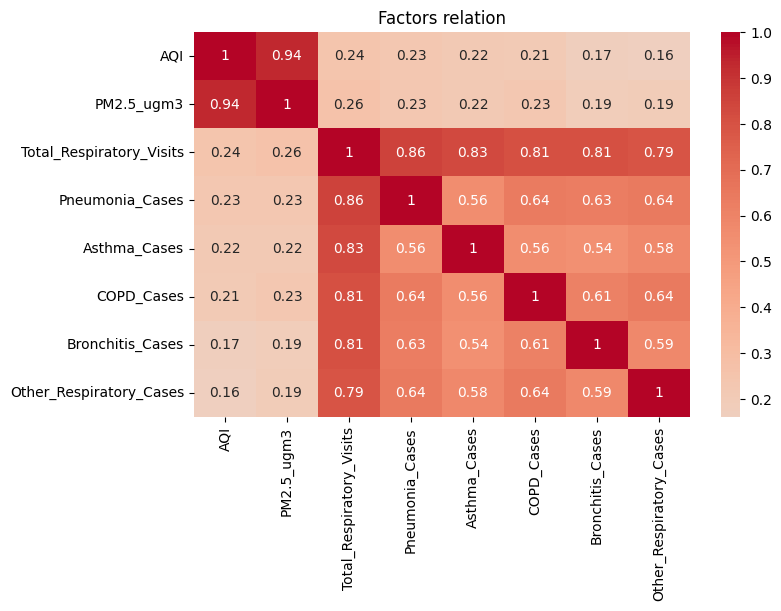

In [14]:

plt.figure(figsize=(8, 5))
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Factors relation')
plt.show()

In [15]:
df.head()

,AQI,PM2.5_ugm3,Total_Respiratory_Visits,Pneumonia_Cases,Asthma_Cases,COPD_Cases,Bronchitis_Cases,Other_Respiratory_Cases
Date,,,,,,,,
2025-01-01,79,25.414286,337,85,93,52,77,30
2025-01-02,69,20.659184,343,77,119,53,59,35
2025-01-03,80,25.889796,383,101,121,67,62,32
2025-01-04,66,19.232653,227,58,65,40,44,20
2025-01-05,63,17.806122,175,53,51,27,28,16


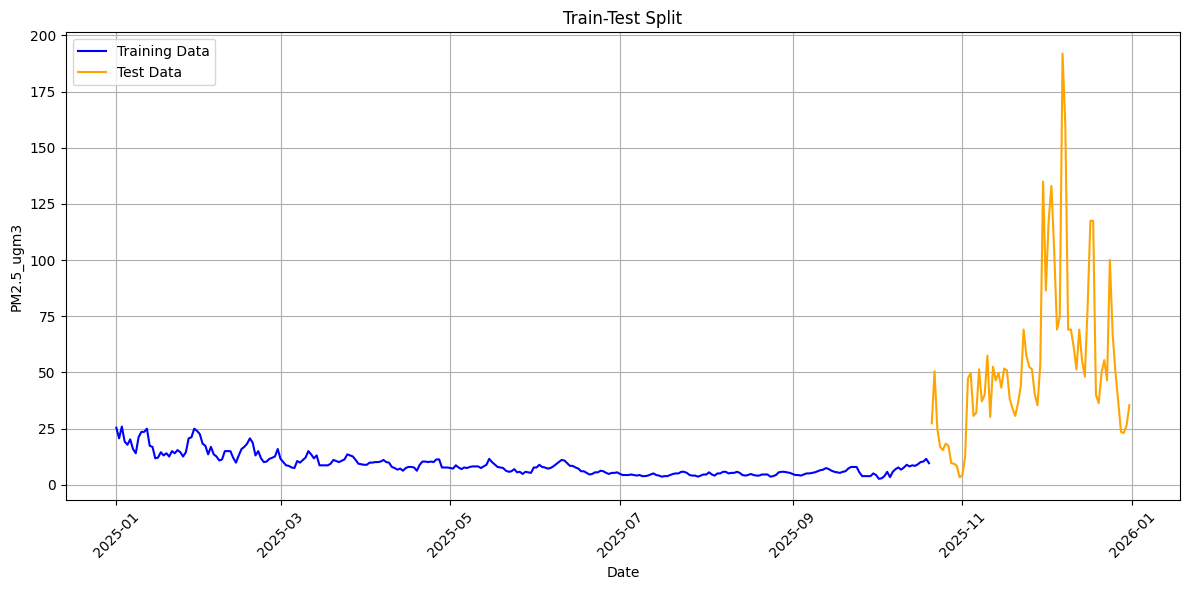

In [16]:
# Split the data into training and testing sets based on date
train_size = int(len(df) * 0.8)  # 80% for training
train, test = df[:train_size], df[train_size:]

# Plot the training and testing sets
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['PM2.5_ugm3'], label='Training Data', color='blue')
plt.plot(test.index, test['PM2.5_ugm3'], label='Test Data', color='orange')
plt.title('Train-Test Split')
plt.xlabel('Date')
plt.ylabel('PM2.5_ugm3')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

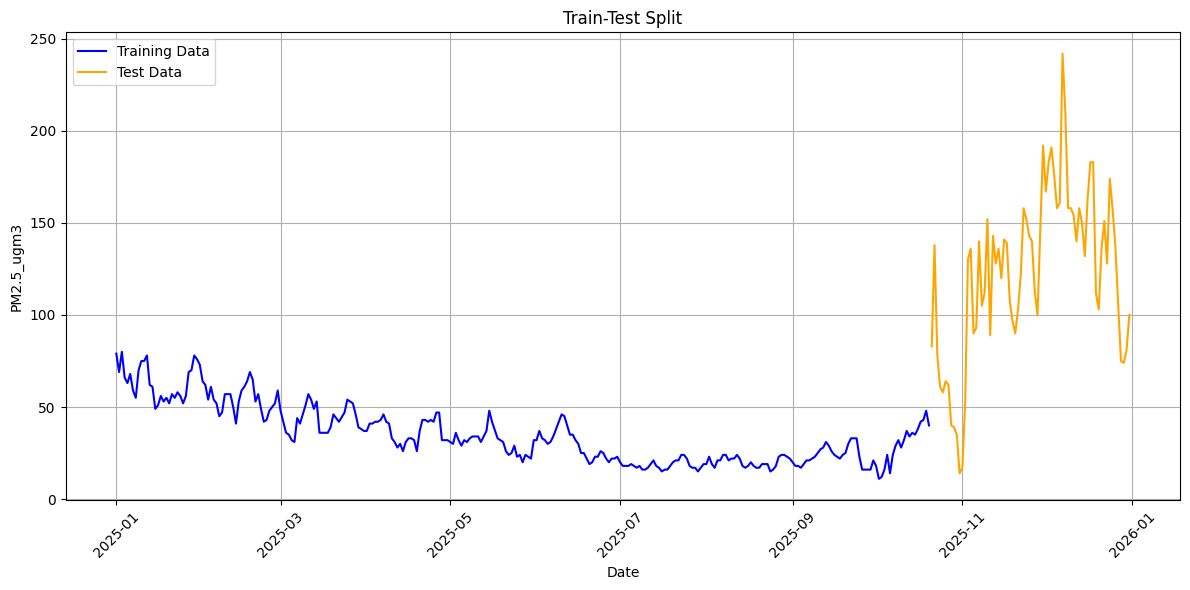

In [17]:
# Split the data into training and testing sets based on date
train_size = int(len(df) * 0.8)  # 80% for training
train, test = df[:train_size], df[train_size:]

# Plot the training and testing sets
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['AQI'], label='Training Data', color='blue')
plt.plot(test.index, test['AQI'], label='Test Data', color='orange')
plt.title('Train-Test Split')
plt.xlabel('Date')
plt.ylabel('PM2.5_ugm3')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
df.head()

,AQI,PM2.5_ugm3,Total_Respiratory_Visits,Pneumonia_Cases,Asthma_Cases,COPD_Cases,Bronchitis_Cases,Other_Respiratory_Cases
Date,,,,,,,,
2025-01-01,79,25.414286,337,85,93,52,77,30
2025-01-02,69,20.659184,343,77,119,53,59,35
2025-01-03,80,25.889796,383,101,121,67,62,32
2025-01-04,66,19.232653,227,58,65,40,44,20
2025-01-05,63,17.806122,175,53,51,27,28,16


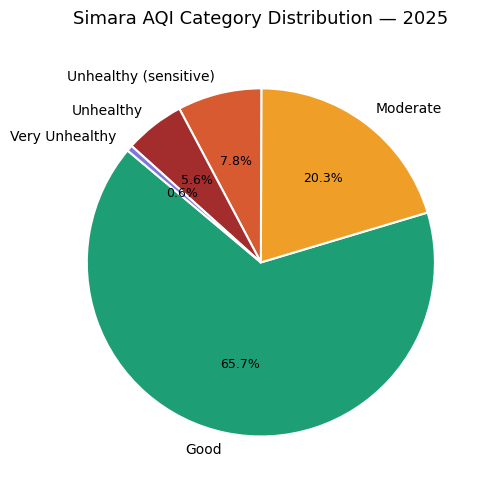

In [19]:

def categorize(aqi):
    if aqi <= 50:   return 'Good'
    elif aqi <= 100: return 'Moderate'
    elif aqi <= 150: return 'Unhealthy (sensitive)'
    elif aqi <= 200: return 'Unhealthy'
    else:            return 'Very Unhealthy'

df['Category'] = df['AQI'].apply(categorize)
counts = df['Category'].value_counts()

order = ['Good', 'Moderate', 'Unhealthy (sensitive)', 'Unhealthy', 'Very Unhealthy']
counts = counts.reindex([o for o in order if o in counts.index])

colors = ['#1D9E75', '#EF9F27', '#D85A30', '#A32D2D', '#7F77DD'][:len(counts)]

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for t in autotexts:
    t.set_fontsize(9)

ax.set_title('Simara AQI Category Distribution — 2025', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6280\2492724475.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', order=order, palette=palette)


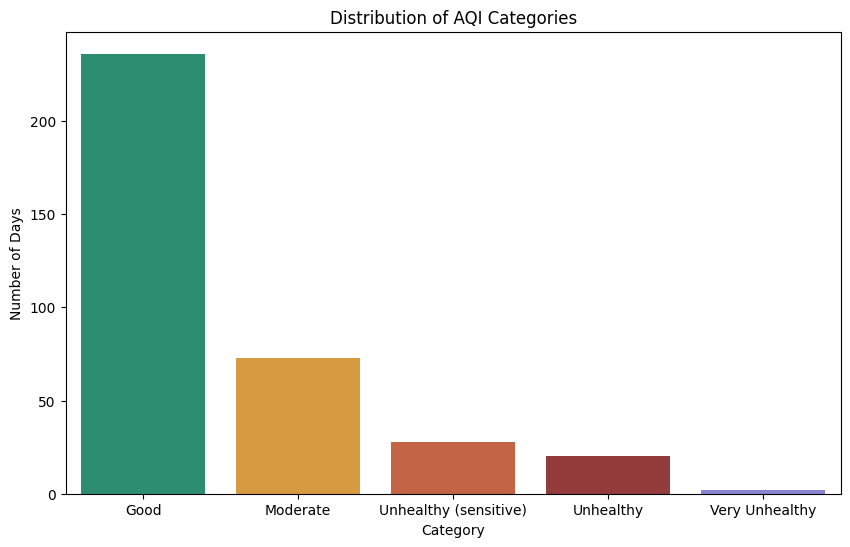

In [20]:
def categorize(aqi):
    if aqi <= 50:    return 'Good'
    elif aqi <= 100: return 'Moderate'
    elif aqi <= 150: return 'Unhealthy (sensitive)'
    elif aqi <= 200: return 'Unhealthy'
    else:            return 'Very Unhealthy'

df['Category'] = df['AQI'].apply(categorize)

order = ['Good', 'Moderate', 'Unhealthy (sensitive)', 'Unhealthy', 'Very Unhealthy']
palette = ['#1D9E75', '#EF9F27', '#D85A30', '#A32D2D', '#7F77DD']

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Category', order=order, palette=palette)
plt.title('Distribution of AQI Categories')
plt.xlabel('Category')
plt.ylabel('Number of Days')
plt.show()

In [24]:
df = pd.read_csv('simara_1year_hourly.csv')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])
print(df.dtypes)  # Date should show datetime64
df.head()

Date                        datetime64[ns]
AQI                                  int64
PM2.5_ugm3                         float64
Total_Respiratory_Visits             int64
Pneumonia_Cases                      int64
Asthma_Cases                         int64
COPD_Cases                           int64
Bronchitis_Cases                     int64
Other_Respiratory_Cases              int64
dtype: object


,Date,AQI,PM2.5_ugm3,Total_Respiratory_Visits,Pneumonia_Cases,Asthma_Cases,COPD_Cases,Bronchitis_Cases,Other_Respiratory_Cases
0,2025-01-01,79,25.414286,337,85,93,52,77,30
1,2025-01-02,69,20.659184,343,77,119,53,59,35
2,2025-01-03,80,25.889796,383,101,121,67,62,32
3,2025-01-04,66,19.232653,227,58,65,40,44,20
4,2025-01-05,63,17.806122,175,53,51,27,28,16


C:\Users\Administrator\AppData\Local\Temp\ipykernel_6280\3563806872.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_avg, x='Month', y='Avg_AQI', palette='RdYlGn_r')


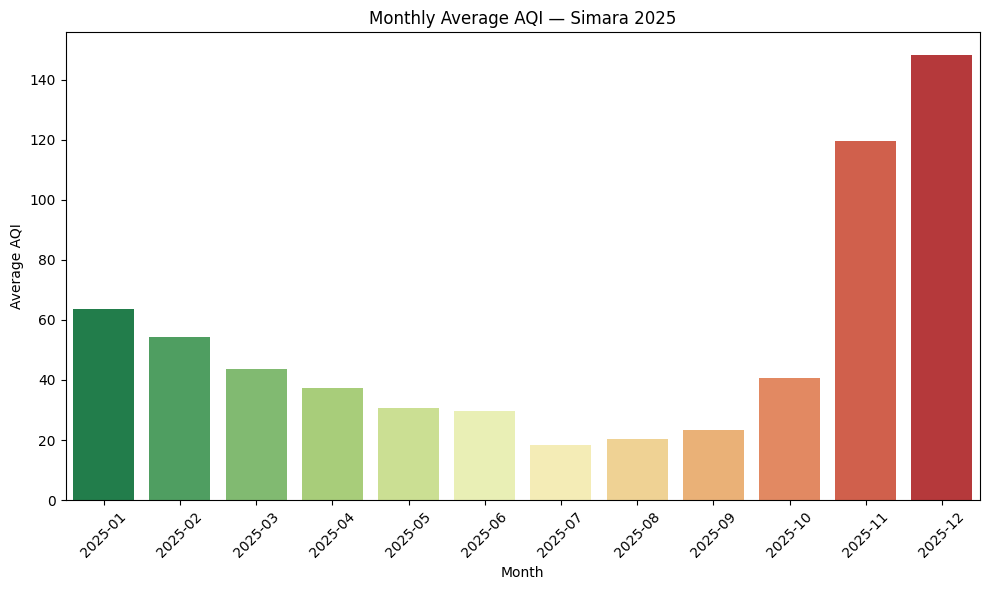

In [25]:
df.columns = df.columns.str.strip()  # removes hidden spaces

monthly_avg = df.groupby(df['Date'].dt.to_period('M'))['AQI'].mean().reset_index()
monthly_avg.columns = ['Month', 'Avg_AQI']
monthly_avg['Month'] = monthly_avg['Month'].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_avg, x='Month', y='Avg_AQI', palette='RdYlGn_r')
plt.title('Monthly Average AQI — Simara 2025')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
monthly = df.groupby(df['Date'].dt.to_period('M')).agg(
    Avg_AQI=('AQI', 'mean'),
    Avg_Visits=('Total_Respiratory_Visits', 'mean')
).reset_index()

monthly['Month'] = monthly['Date'].astype(str)
monthly['Avg_AQI'] = monthly['Avg_AQI'].round(1)
monthly['Avg_Visits'] = monthly['Avg_Visits'].round(0).astype(int)
monthly

,Date,Avg_AQI,Avg_Visits,Month
0,2025-01,63.7,318,2025-01
1,2025-02,54.5,314,2025-02
2,2025-03,43.8,322,2025-03
3,2025-04,37.3,314,2025-04
4,2025-05,30.5,311,2025-05
5,2025-06,29.6,309,2025-06
6,2025-07,18.4,312,2025-07
7,2025-08,20.2,305,2025-08
8,2025-09,23.3,303,2025-09
9,2025-10,40.8,319,2025-10


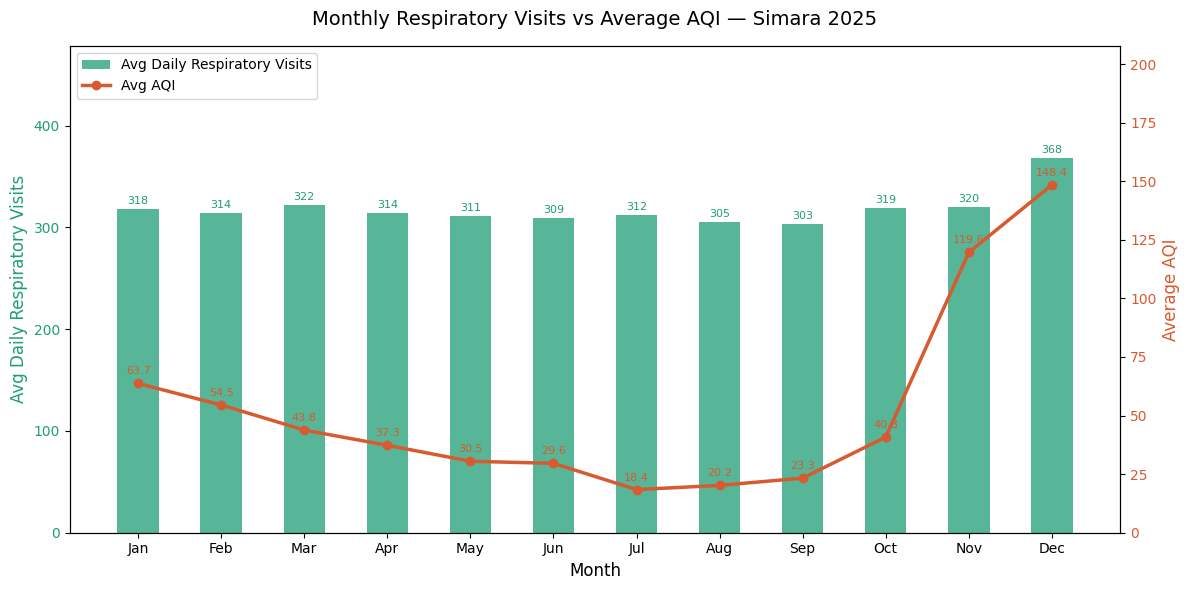

In [ ]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

x = np.arange(len(monthly))

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bars — Respiratory Visits
bars = ax1.bar(x, monthly['Avg_Visits'], color='#1D9E75', alpha=0.75,
               width=0.5, label='Avg Daily Respiratory Visits')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Avg Daily Respiratory Visits', fontsize=12, color='#1D9E75')
ax1.tick_params(axis='y', labelcolor='#1D9E75')
ax1.set_xticks(x)
ax1.set_xticklabels(month_labels[:len(monthly)])
ax1.set_ylim(0, monthly['Avg_Visits'].max() * 1.3)

# Annotate bars
for bar, val in zip(bars, monthly['Avg_Visits']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', va='bottom', fontsize=8, color='#1D9E75')

# Line — Avg AQI
ax2 = ax1.twinx()
ax2.plot(x, monthly['Avg_AQI'], color='#D85A30', linewidth=2.5,
         marker='o', markersize=6, label='Avg AQI')
ax2.set_ylabel('Average AQI', fontsize=12, color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')
ax2.set_ylim(0, monthly['Avg_AQI'].max() * 1.4)

# Annotate AQI line
for xi, val in zip(x, monthly['Avg_AQI']):
    ax2.text(xi, val + 3, str(val), ha='center', va='bottom',
             fontsize=8, color='#D85A30')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Monthly Respiratory Visits vs Average AQI — Simara 2025', fontsize=14, pad=15)
fig.tight_layout()
plt.show()

In [27]:
corr = df['AQI'].corr(df['Total_Respiratory_Visits'])
print(f"Pearson Correlation (AQI vs Respiratory Visits): {corr:.4f}")

Pearson Correlation (AQI vs Respiratory Visits): 0.2449


In [28]:
corr = df['PM2.5_ugm3'].corr(df['AQI'])
print(f"Pearson Correlation (PM2.5 vs AQI): {corr:.4f}")

Pearson Correlation (PM2.5 vs AQI): 0.9376


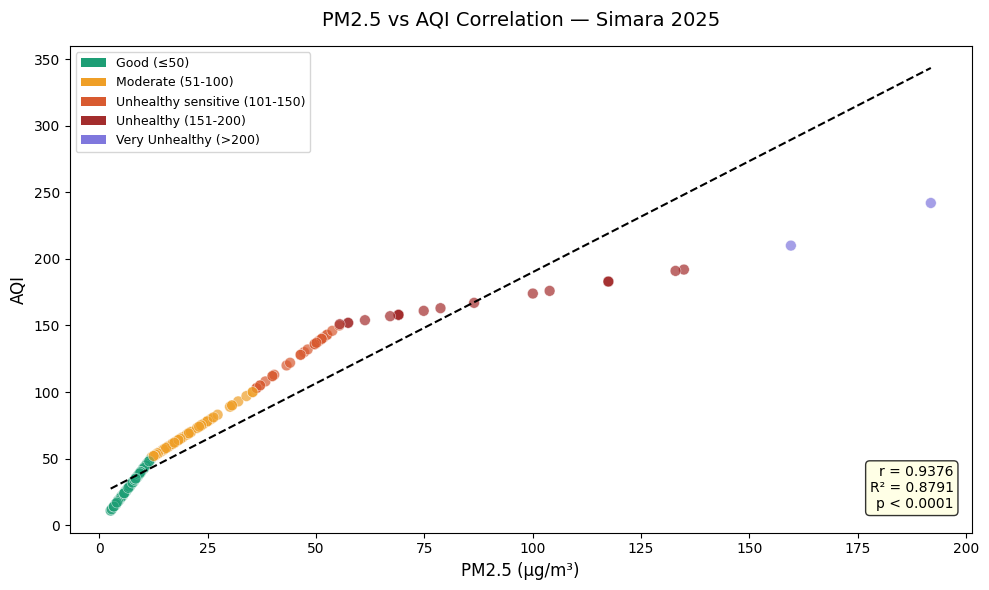

In [29]:
slope, intercept, r, p, se = stats.linregress(df['PM2.5_ugm3'], df['AQI'])

x_line = np.linspace(df['PM2.5_ugm3'].min(), df['PM2.5_ugm3'].max(), 200)
y_line = slope * x_line + intercept

def get_color(aqi):
    if aqi <= 50:    return '#1D9E75'
    elif aqi <= 100: return '#EF9F27'
    elif aqi <= 150: return '#D85A30'
    elif aqi <= 200: return '#A32D2D'
    else:            return '#7F77DD'

colors = df['AQI'].apply(get_color)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['PM2.5_ugm3'], df['AQI'], c=colors, alpha=0.7,
           edgecolors='white', linewidth=0.4, s=60)

ax.plot(x_line, y_line, color='black', linewidth=1.5,
        linestyle='--', label=f'Regression line (R² = {r**2:.3f})')

ax.set_xlabel('PM2.5 (µg/m³)', fontsize=12)
ax.set_ylabel('AQI', fontsize=12)
ax.set_title('PM2.5 vs AQI Correlation — Simara 2025', fontsize=14, pad=15)
ax.legend(fontsize=10)

# Color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1D9E75', label='Good (≤50)'),
    Patch(facecolor='#EF9F27', label='Moderate (51-100)'),
    Patch(facecolor='#D85A30', label='Unhealthy sensitive (101-150)'),
    Patch(facecolor='#A32D2D', label='Unhealthy (151-200)'),
    Patch(facecolor='#7F77DD', label='Very Unhealthy (>200)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

ax.text(0.98, 0.05, f'r = {corr:.4f}\nR² = {r**2:.4f}\np < 0.0001',
        transform=ax.transAxes, fontsize=10, ha='right',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()